In [1]:
import os
from pathlib import Path

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
data_dir = "../../Data"
    
import occultence
occultence.version()

'0.5.13'

file_007


(0.99, 1.015)

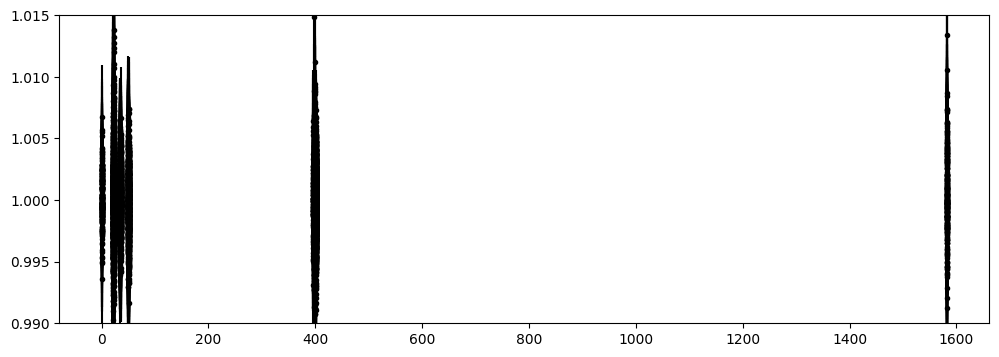

In [2]:
pre_bin = False

all_files = glob.glob(f"{data_dir}/file_*")
all_stars = pd.read_csv(f"{data_dir}/star_info.csv")

#select star/lightcurve to analyse
i = 5
file_to_use = all_files[i]
file_stem = Path(file_to_use).stem

#get light curve of selected star
data = pd.read_csv(file_to_use)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

#get stellar parameters
star_info = all_stars[all_stars["TARGET"]==file_stem]

R_star = star_info["RAD"].values[0]
M_star = star_info["MASS"].values[0]
T_star = star_info["TEFF"].values[0]
name = star_info['TARGET'].values[0]
print(name)

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = name,
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':R_star*u.R_sun, 'M_star':M_star*u.M_sun,
                           'Teff':T_star * u.K})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



In [4]:
targ

<🌟 Lightcurve file_007 (6970t) 🌟>

In [5]:
targ_with_transit = targ.inject_transit(per=10*u.d, 
                                        epoch=0.025 * u.d, 
                                        inc=90 * u.degree, 
                                        rp=2 * u.R_earth, 
                                        ld=[0.3,0.3])

In [7]:
# targ_with_transit.bin(dt=20*u.minute).time

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='transit_model'>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

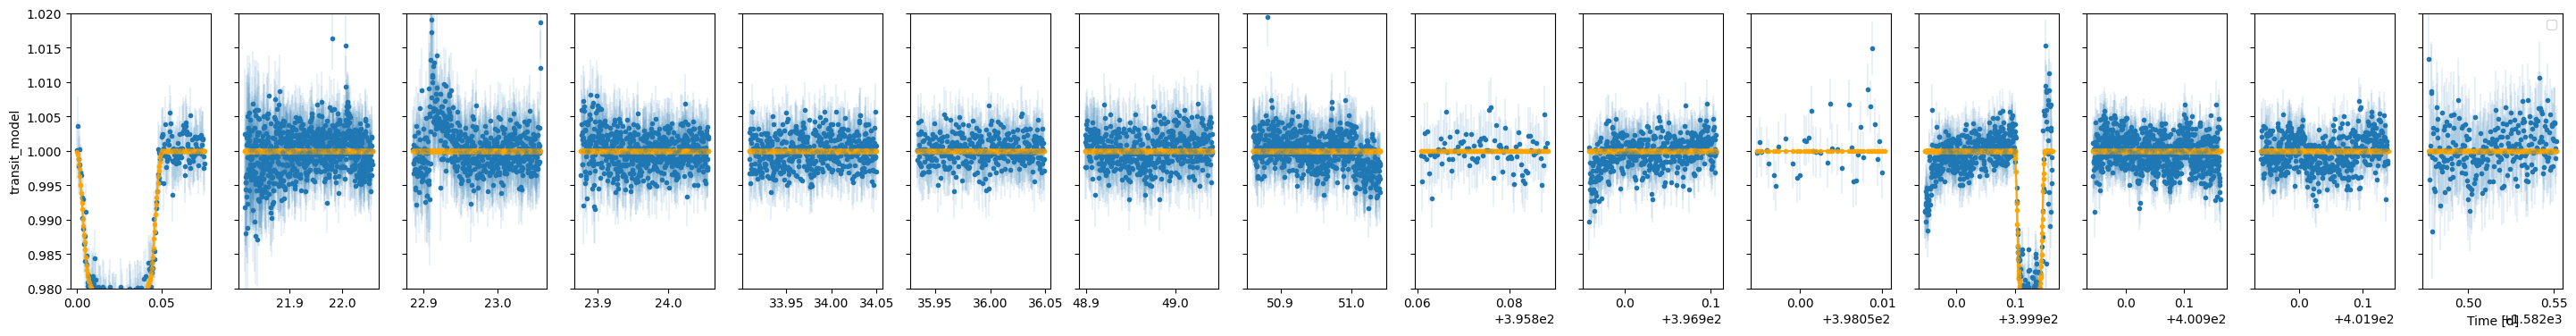

In [8]:
ax=targ_with_transit.plot(ylims=[0.95,1.05])
targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-",)

Running BLS Search
Number of Periods Checked:  100000
Period:  5.882368583268184
Duration:  0.04
Depth:  0.02120888984028127
Power:  85.5468425126643


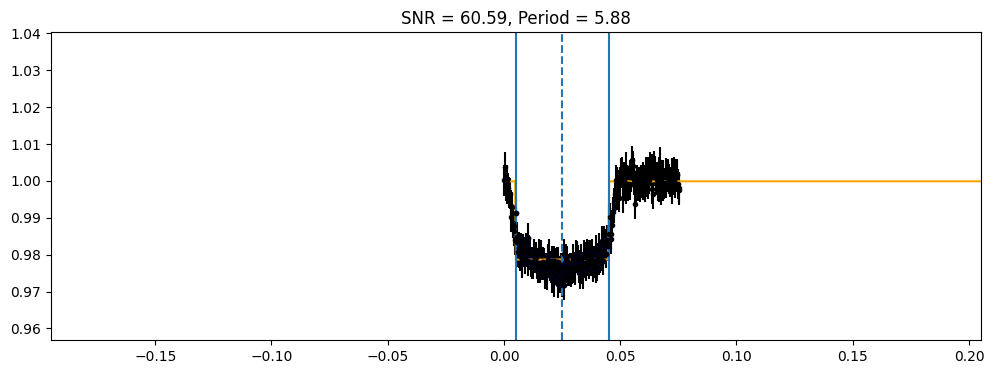

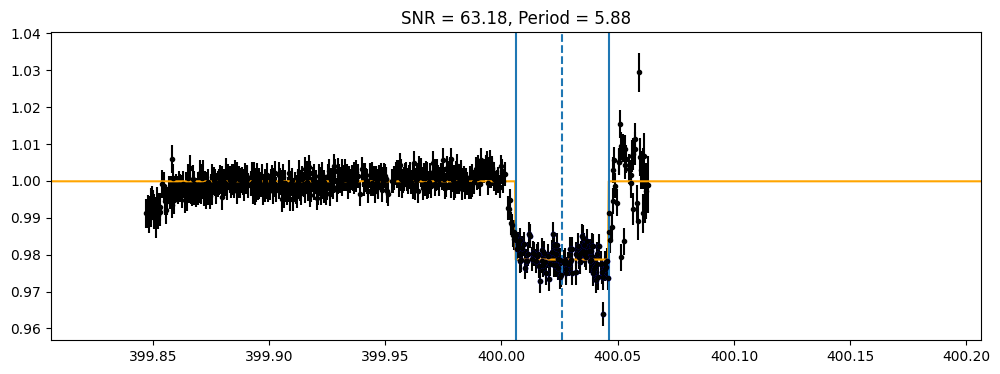

In [9]:
a = targ_with_transit.find_transits(transit_durations=[0.01,0.02,0.03,0.04],
                            minimum_period=0.5, 
                            maximum_period=30,
                            oversample=10,
                            obj="snr",
                            minimum_n_transit=2,
                           verbose=True, plot=True,
                            nperiods=100000)

In [10]:
a[0].metadata

{'name': 'file_007_inject_bls_0',
 'target': 'file_007',
 'R_star': <Quantity 0.13 solRad>,
 'M_star': <Quantity 0.11 solMass>,
 'Teff': <Quantity 2863. K>,
 'injected_planet': {'period': [<Quantity 10. d>],
  'epoch': [<Quantity 0.025 d>],
  'inc': [<Quantity 90. deg>],
  'rp': [<Quantity 2. earthRad>],
  'a': [<Quantity 9.35912726 solRad>],
  'a_Rs': [<Quantity 71.99328659>],
  'ld': [[0.3, 0.3]],
  'depth': [<Quantity 0.01989353>],
  'duration': [<Quantity 0.05045206 d>]},
 'BLS_transits_found': True,
 'BLS_transits_ind': array([  15,   16,   17,   18,   19,   20,   21,   22,   23,   24,   25,
          26,   27,   28,   29,   30,   31,   32,   33,   34,   35,   36,
          37,   38,   39,   40,   41,   42,   43,   44,   45,   46,   47,
          48,   49,   50,   51,   52,   53,   54,   55,   56,   57,   58,
          59,   60,   61,   62,   63,   64,   65,   66,   67,   68,   69,
          70,   71,   72,   73,   74,   75,   76,   77,   78,   79,   80,
          81,   82,   83, 

In [11]:
per=2.55*u.d
epoch=0.025 * u.d
inc=90 * u.degree
rp=1 * u.R_earth
ld=[0.3,0.3]

planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
                                                          minimum_planet_radius=rp, 
                                                          maximum_planet_radius=rp,
                                                          minimum_period=per, 
                                                          maximum_period=per,
                                                        )
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,0.40654,0.037959,0.000103,1.0,0.004973383359304848,0.030021,0.096795,3.7635307841569907 solRad,28.95023680120762,0.0,...,0.0,0.0,0.0,0.0,0.0,file_007_inject,0.13 solRad,0.11 solMass,None,None


In [12]:
# lcs_with_transits, planets = targ.inject_lots_of_transits(nfake=10,
#                                                                   minimum_planet_radius=rp,
#                                                                   maximum_planet_radius=rp,
#                                                                   minimum_period=per,
#                                                                   maximum_period=10*u.d,
#                                                                   ld=ld,
#                                                           )

In [13]:
# lcs_with_transits

Saved LC as: ../../Results//file_007.pkl
1/5...
Saved LC as: ../../Results//file_007_inject0.pkl
Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...

            0.0860832137733142% of data is flagged as cosmics ⚡.
            
Saved LC as: ../../Results//file_007_inject0_clean.pkl
Time to clean LC: 1.6629838943481445


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 1 flare candidates with >30.0 s over 3$\sigma$
            


Saved LC as: ../../Results//file_007_inject0_clean_sigmaclipped_flaresremoved.pkl
Time to remove flares: 2.6368720531463623
Running BLS Search
Number of Periods Checked:  100000
Period:  0.6717835060327388
Duration:  0.03
Depth:  0.01199861125173806
Power:  8.209364616739164
Time to BLS before detrending: 4.418742895126343
Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-5.49898752 -6.89699516 -2.30258509]
Initial Params: AMP =  0.0010108182211681388 , SQEXP=  0.10000000000000002 , JITTER =  0.0040909113260965985
Initial ln-likelihood: 511.78


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Fitted GP HPs: [-27.99428365 -28.3144255   -3.56753878]
Fitted Params: AMP =  5.048952049178989e-13 , SQEXP=  0.02822523668618383 , JITTER =  6.954038454544135e-13
Final ln-likelihood: 1308.03


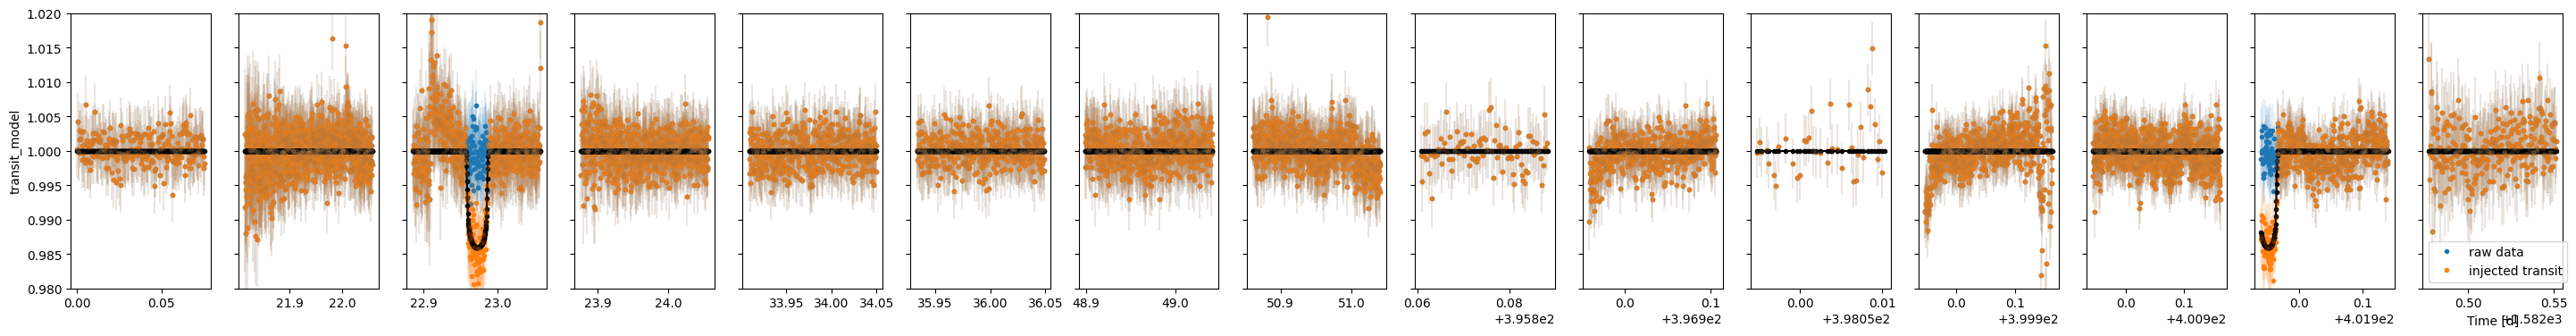

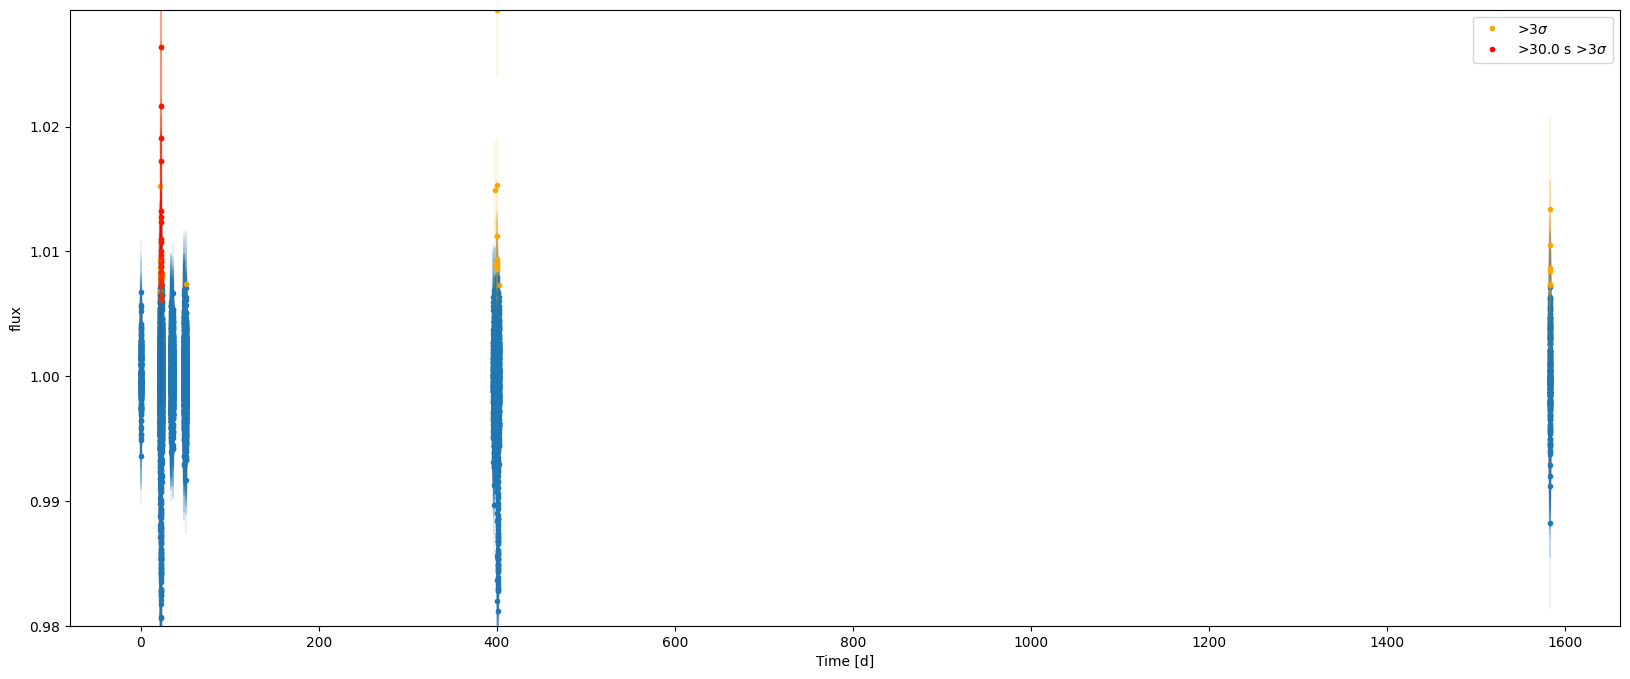

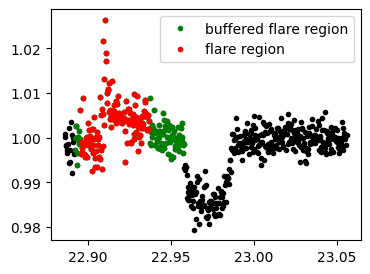

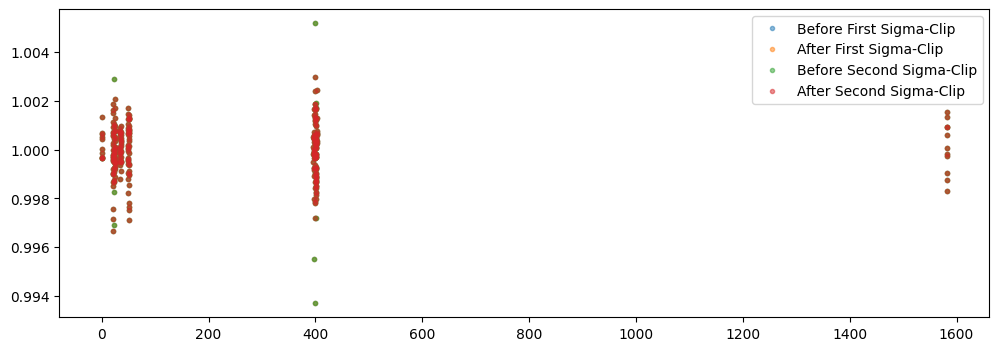

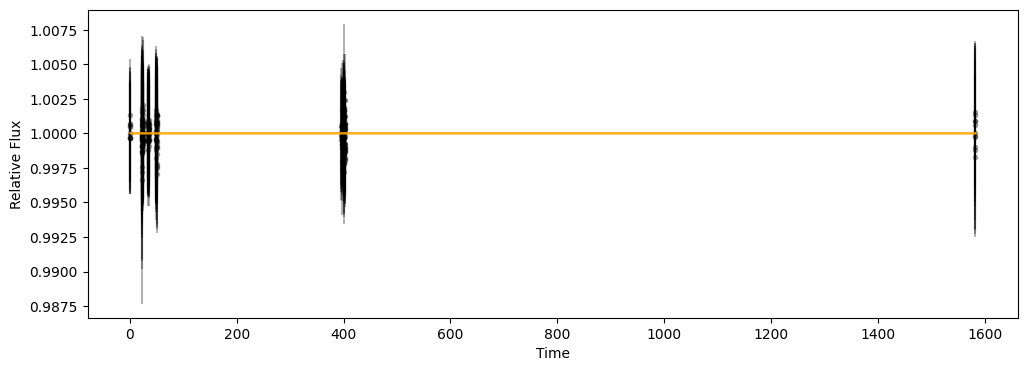

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved LC as: ../../Results//file_007_inject0_clean_sigmaclipped_flaresremoved_bin.pkl
Time to detrend: 3.1951498985290527
Running BLS Search
Number of Periods Checked:  100000
Period:  0.6693947926291459
Duration:  0.03
Depth:  0.012471862881531837
Power:  11.845707577399642
Saved LC as: ../../Results//file_007_inject0_clean_sigmaclipped_flaresremoved_bin_bls_0.pkl
Time to BLS search: 4.56586480140686
Transit was found - checking if it matches the injected transit!
Injected planet parameters: {'period': [<Quantity 2.3979697 d>], 'epoch': [<Quantity 1.39040047 d>], 'inc': [<Quantity 1.57006637 rad>], 'rp': [<Quantity 1.55080838 earthRad>], 'a': [<Quantity 3.61241647 solRad>], 'a_Rs': [<Quantity 27.78781897>], 'ld': [[0.3, 0.3]], 'depth': [<Quantity 0.01196102>], 'duration': [<Quantity 0.03047595 d>]}
Recovered planet parameters: {'period': [<Quantity 0.66939479 d>, <Quantity 0.66939479 d>, <Quantity 0.66939479 d>], 'depth': [0.012471862881532125, 0.012471862881532125, 0.0124718628815321

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 1 flare candidates with >30.0 s over 3$\sigma$
            


Saved LC as: ../../Results//file_007_inject1_clean_sigmaclipped_flaresremoved.pkl
Time to remove flares: 2.637054920196533
Running BLS Search
Number of Periods Checked:  100000
Period:  2.5073384993309267
Duration:  0.02
Depth:  0.017935499248211525
Power:  13.260714023851374
Time to BLS before detrending: 4.286662817001343
Fitting rotation with square-exponential GP...


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Initial Parameter Vector:  [-5.49016795 -6.884285   -2.30258509]
Initial Params: AMP =  0.0010237478725790192 , SQEXP=  0.10000000000000002 , JITTER =  0.004127150970751599
Initial ln-likelihood: 510.42
Fitted GP HPs: [-28.06413655 -28.46661953  -3.28137275]
Fitted Params: AMP =  4.3361492318537356e-13 , SQEXP=  0.03757663793075241 , JITTER =  6.4848563331748e-13
Final ln-likelihood: 1305.71


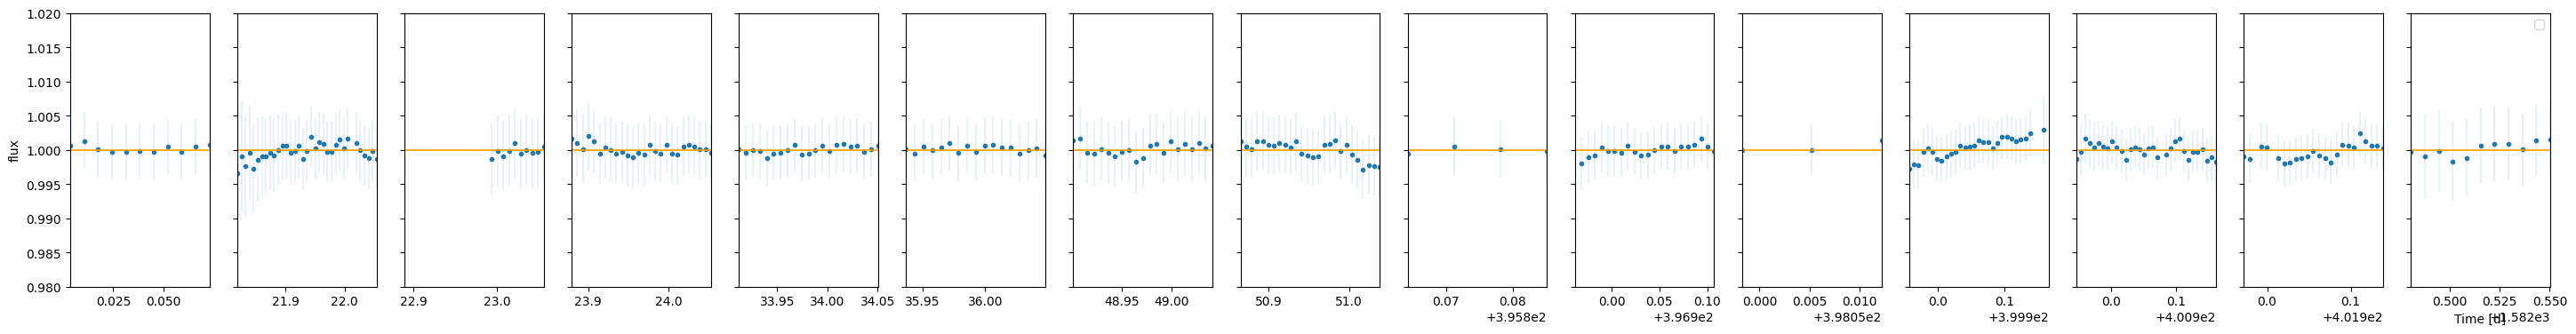

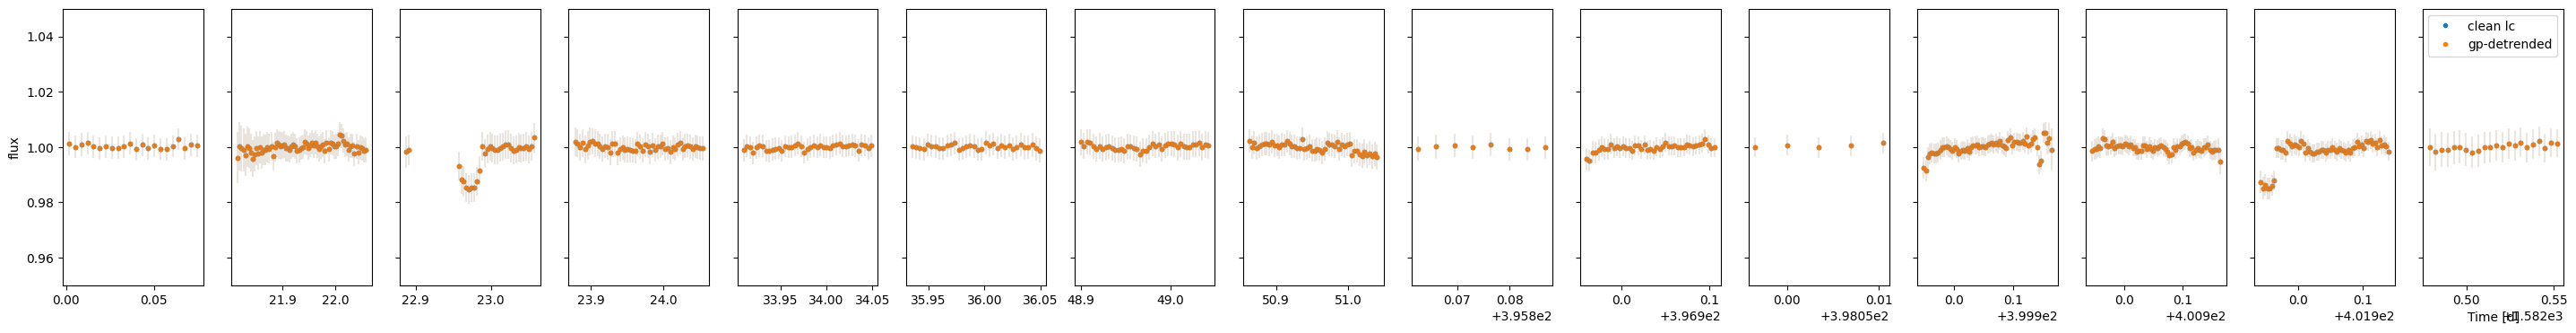

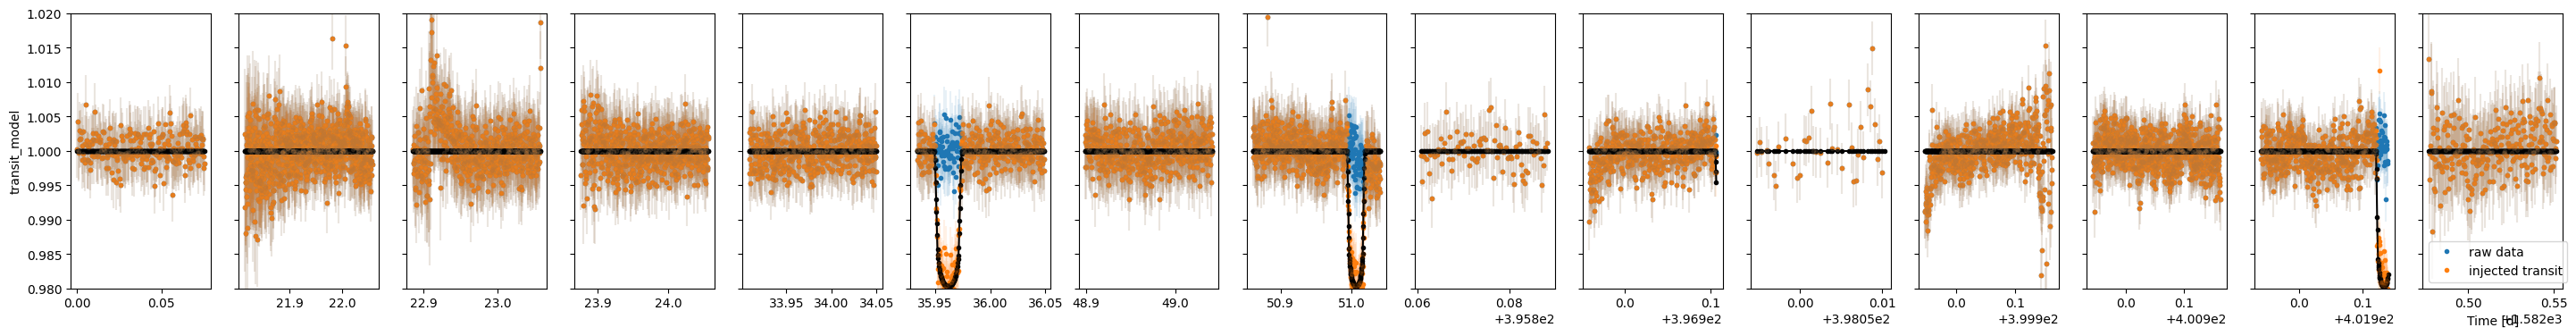

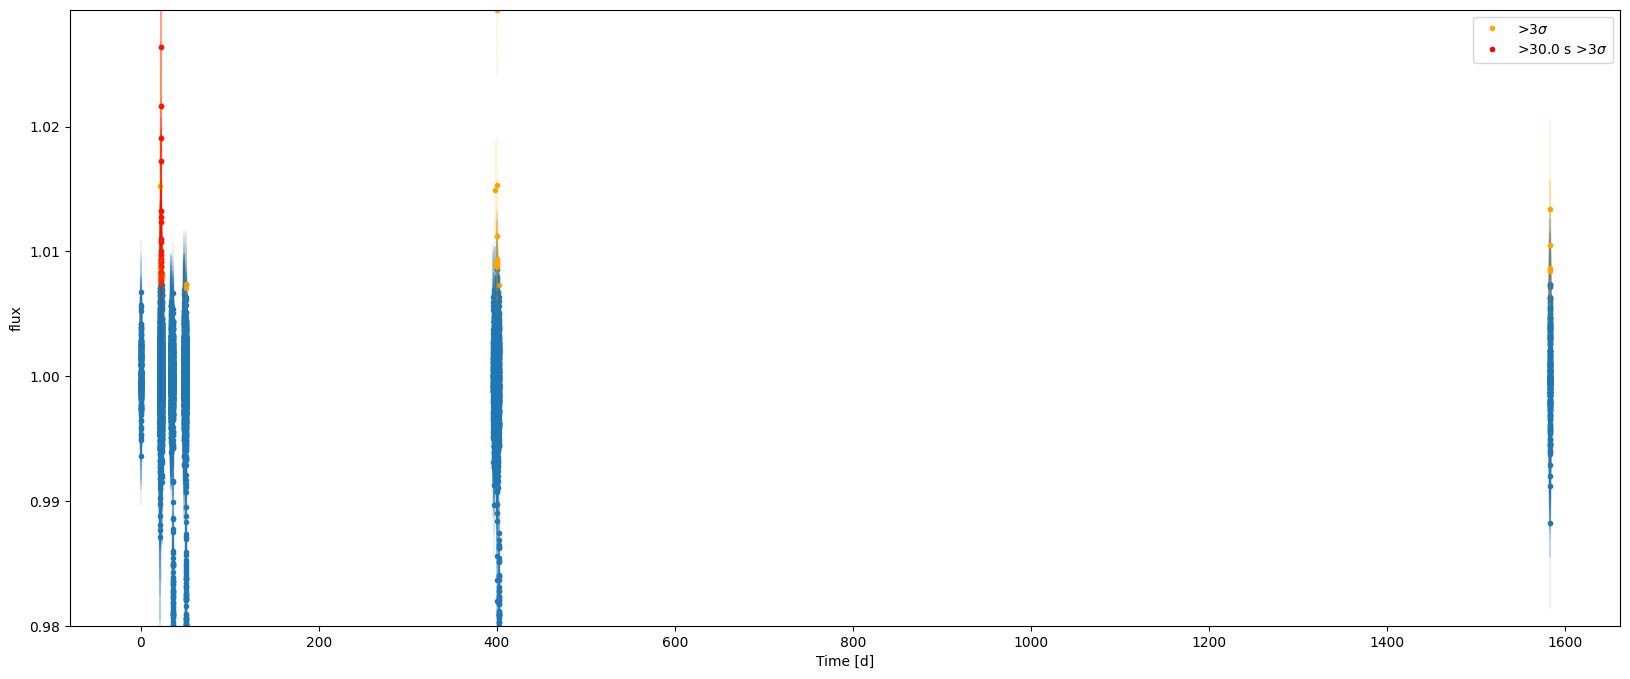

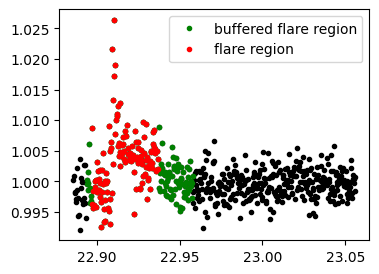

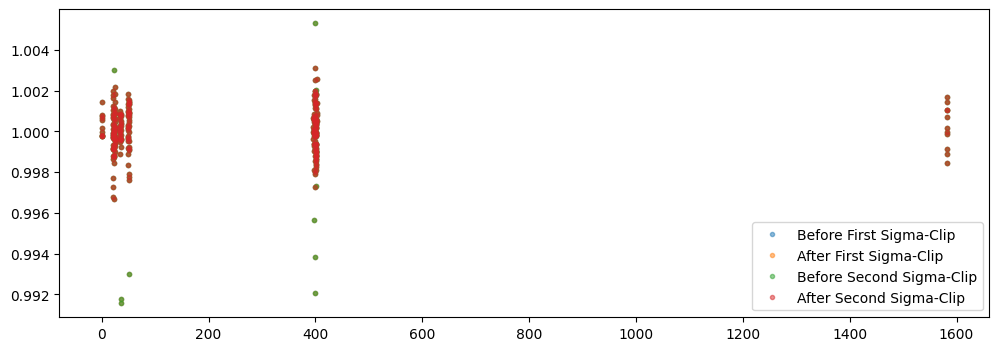

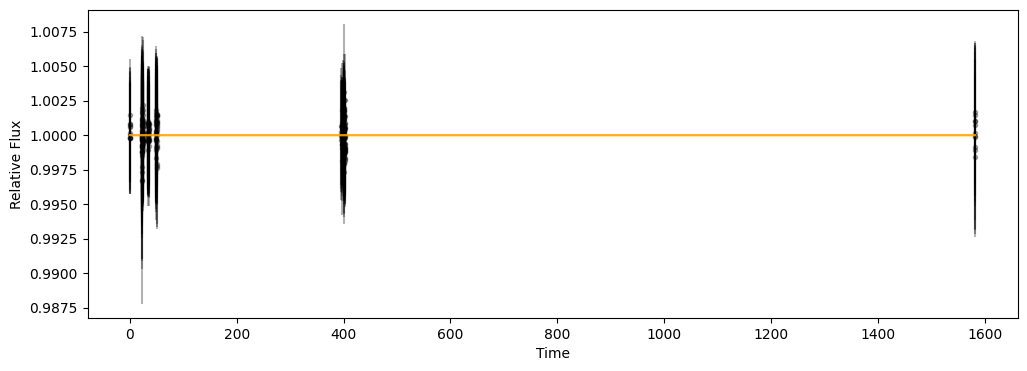

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved LC as: ../../Results//file_007_inject1_clean_sigmaclipped_flaresremoved_bin.pkl
Time to detrend: 6.213454961776733
Running BLS Search
Number of Periods Checked:  100000
Period:  5.014633580592181
Duration:  0.02
Depth:  0.01793990408056483
Power:  19.698455773044905
Saved LC as: ../../Results//file_007_inject1_clean_sigmaclipped_flaresremoved_bin_bls_0.pkl
Time to BLS search: 4.451104164123535
Transit was found - checking if it matches the injected transit!
Injected planet parameters: {'period': [<Quantity 1.25366821 d>], 'epoch': [<Quantity 0.85900123 d>], 'inc': [<Quantity 1.56520555 rad>], 'rp': [<Quantity 1.83731754 earthRad>], 'a': [<Quantity 2.34435708 solRad>], 'a_Rs': [<Quantity 18.03351601>], 'ld': [[0.3, 0.3]], 'depth': [<Quantity 0.01678883>], 'duration': [<Quantity 0.02491255 d>]}
Recovered planet parameters: {'period': [<Quantity 5.01463358 d>, <Quantity 5.01463358 d>, <Quantity 5.01463358 d>], 'depth': [0.017939904080564895, 0.017939904080564895, 0.01793990408056489

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 1 flare candidates with >30.0 s over 3$\sigma$
            


Saved LC as: ../../Results//file_007_inject2_clean_sigmaclipped_flaresremoved.pkl
Time to remove flares: 2.5388548374176025
Running BLS Search
Number of Periods Checked:  100000
Period:  0.6348264898865672
Duration:  0.03
Depth:  0.014970375727067777
Power:  8.873542763528766
Time to BLS before detrending: 4.3672521114349365
Fitting rotation with square-exponential GP...


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Initial Parameter Vector:  [-5.48991251 -6.87752786 -2.30258509]
Initial Params: AMP =  0.0010306889007340844 , SQEXP=  0.10000000000000002 , JITTER =  0.0041282053486367265
Initial ln-likelihood: 522.91
Fitted GP HPs: [-27.92167187 -28.20030007  -3.07311307]
Fitted Params: AMP =  5.6593335703463e-13 , SQEXP=  0.04627686703543897 , JITTER =  7.477767886823616e-13
Final ln-likelihood: 1337.33


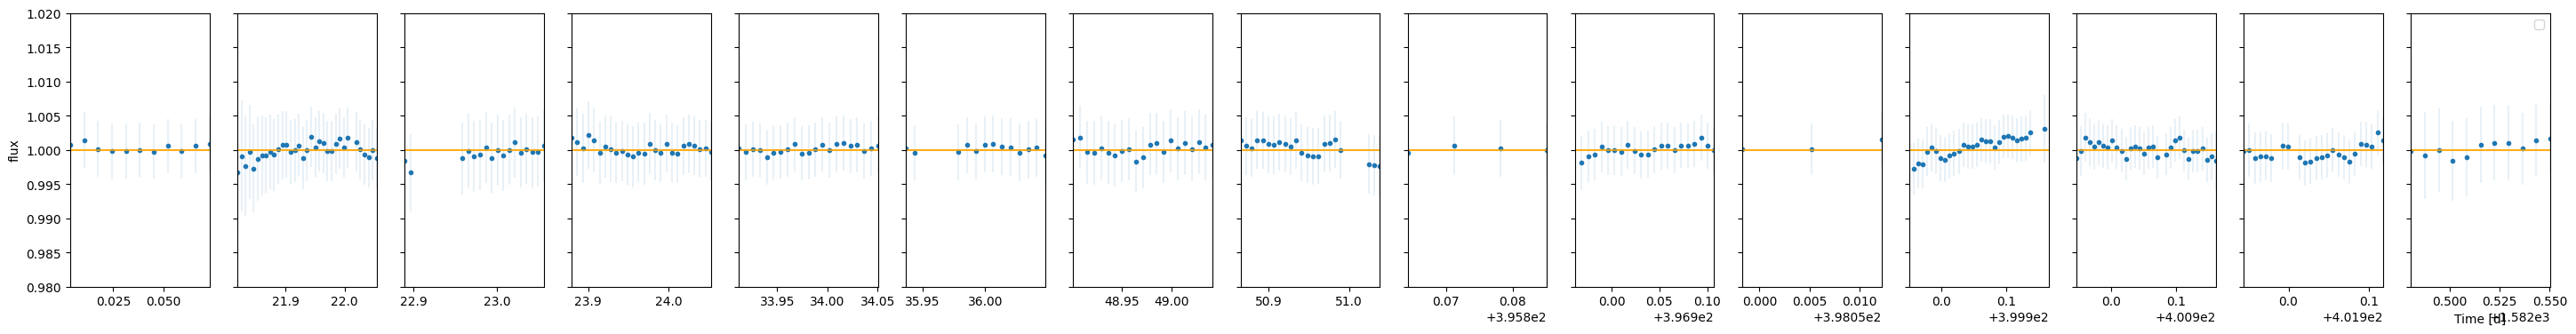

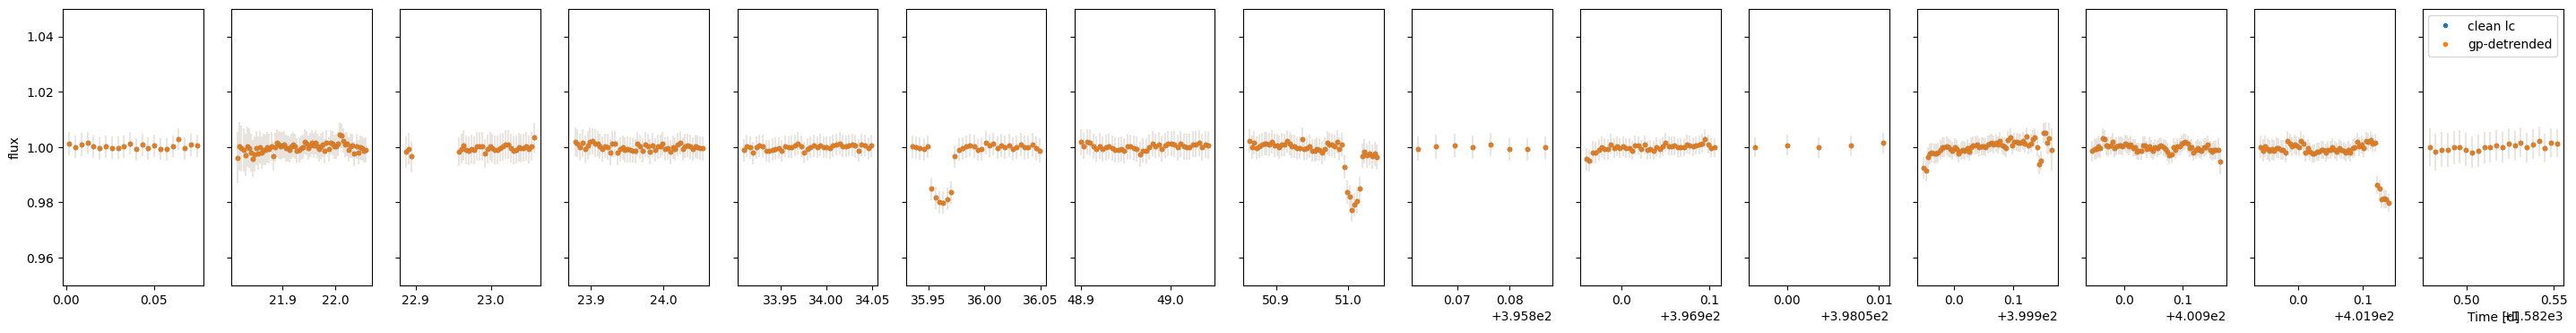

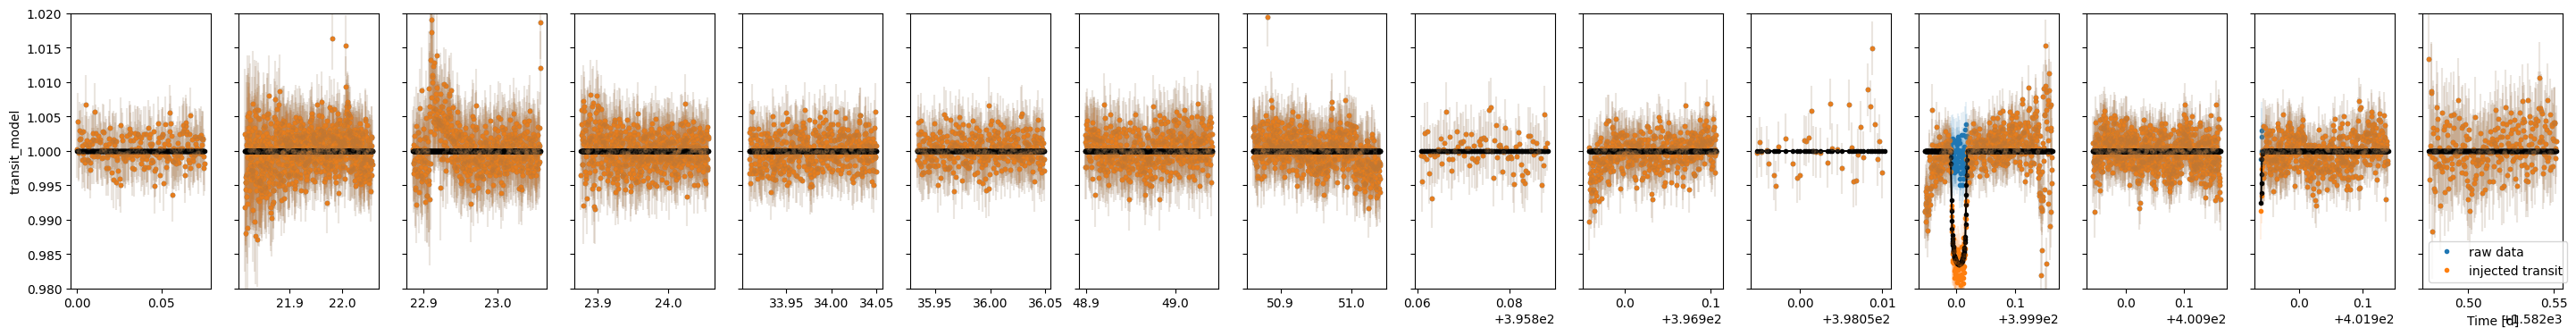

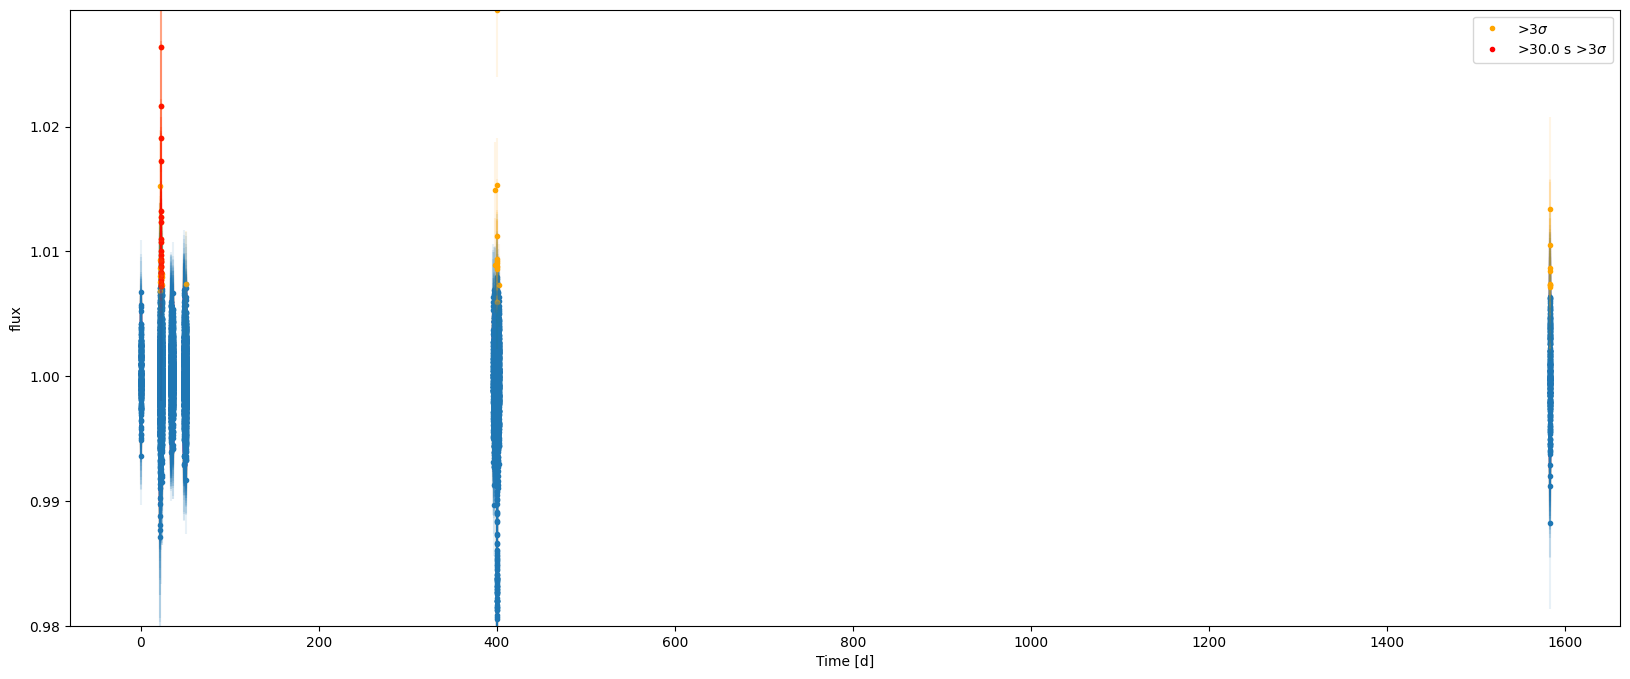

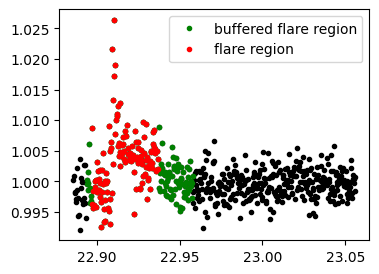

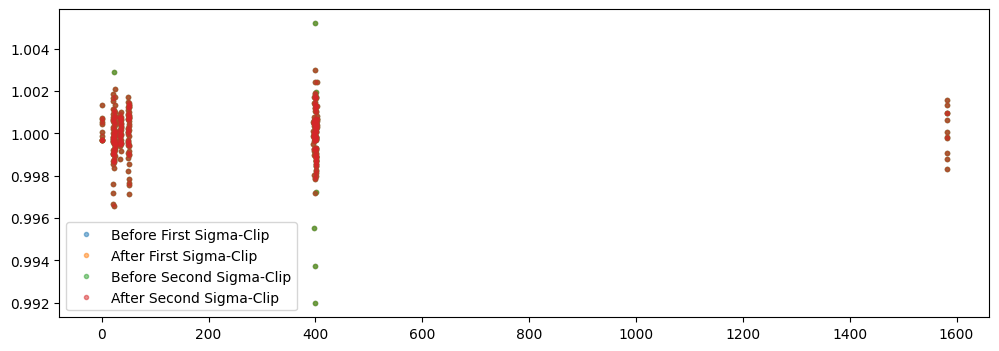

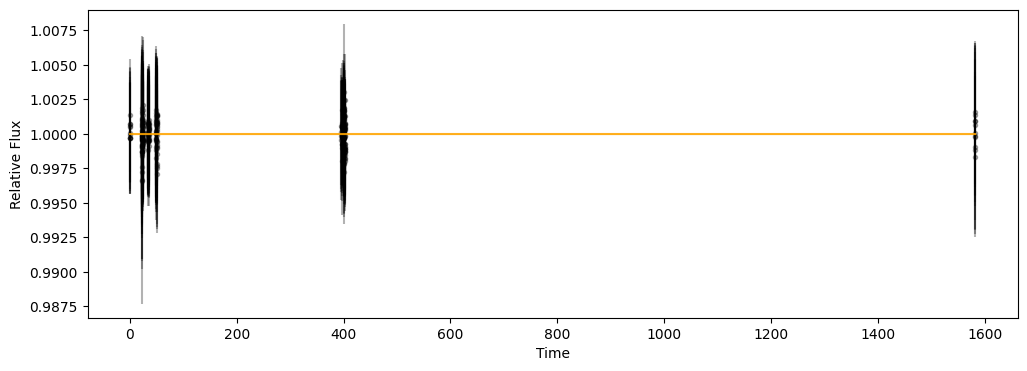

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved LC as: ../../Results//file_007_inject2_clean_sigmaclipped_flaresremoved_bin.pkl
Time to detrend: 8.543122053146362
Running BLS Search
Number of Periods Checked:  100000
Period:  13.330553671216592
Duration:  0.03
Depth:  0.014778451971509714
Power:  12.147995155915396
Saved LC as: ../../Results//file_007_inject2_clean_sigmaclipped_flaresremoved_bin_bls_0.pkl
Time to BLS search: 4.518279075622559
Transit was found - checking if it matches the injected transit!
Injected planet parameters: {'period': [<Quantity 1.92387731 d>], 'epoch': [<Quantity 1.66188411 d>], 'inc': [<Quantity 1.56929161 rad>], 'rp': [<Quantity 1.67867423 earthRad>], 'a': [<Quantity 3.11903514 solRad>], 'a_Rs': [<Quantity 23.992578>], 'ld': [[0.3, 0.3]], 'depth': [<Quantity 0.01401473>], 'duration': [<Quantity 0.02854124 d>]}
Recovered planet parameters: {'period': [<Quantity 13.33055367 d>, <Quantity 13.33055367 d>], 'depth': [0.013224853045625817, 0.013224853045625817], 'duration': [<Quantity 0.03 d>, <Quantity

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 1 flare candidates with >30.0 s over 3$\sigma$
            


Saved LC as: ../../Results//file_007_inject3_clean_sigmaclipped_flaresremoved.pkl
Time to remove flares: 2.6022121906280518
Running BLS Search
Number of Periods Checked:  100000
Period:  0.911424526289531
Duration:  0.02
Depth:  0.012017117109826005
Power:  9.257809982187192
Time to BLS before detrending: 4.439074993133545


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-5.49016795 -6.87285327 -2.30258509]
Initial Params: AMP =  0.0010355182309205707 , SQEXP=  0.10000000000000002 , JITTER =  0.004127150970751599
Initial ln-likelihood: 510.32
Fitted GP HPs: [-28.01344187 -28.3761682   -3.30838692]
Fitted Params: AMP =  4.7466448044539e-13 , SQEXP=  0.03657512471726497 , JITTER =  6.822079535233583e-13
Final ln-likelihood: 1305.72


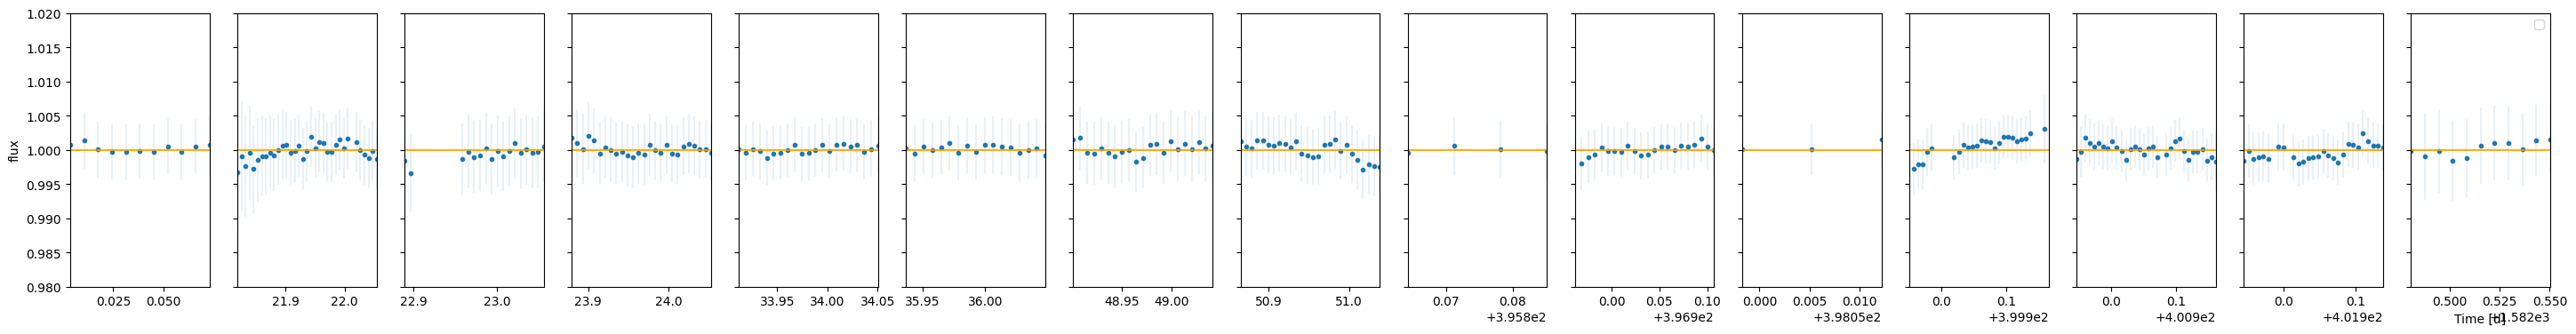

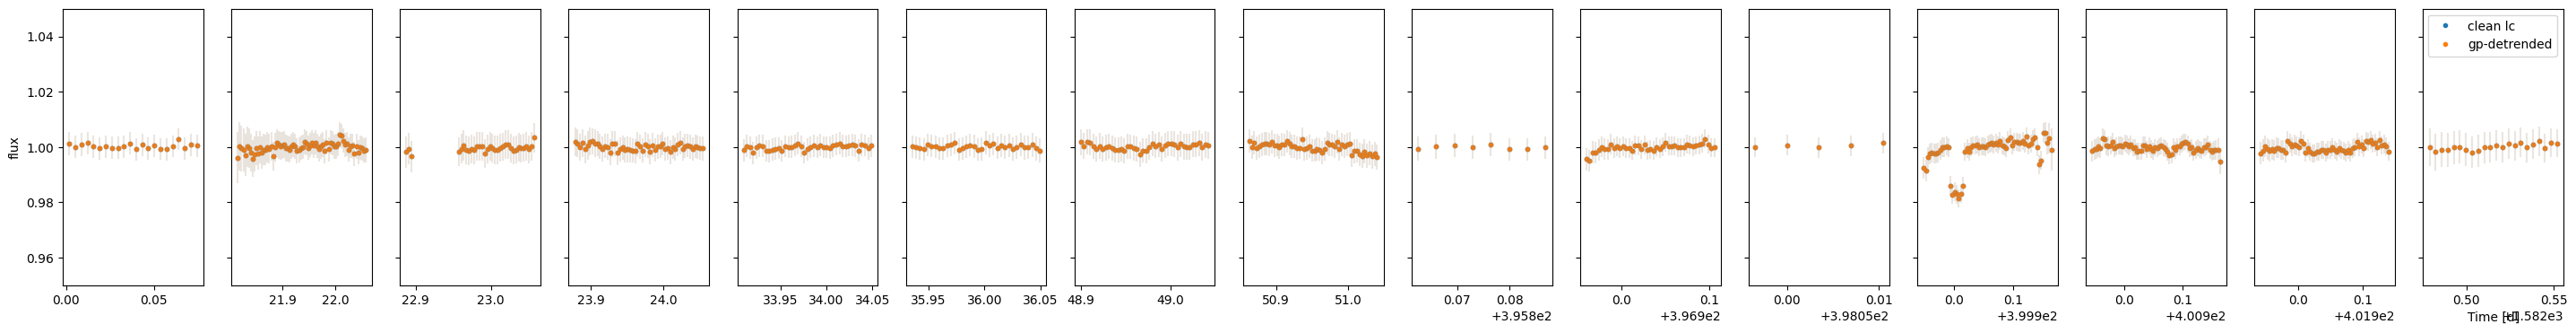

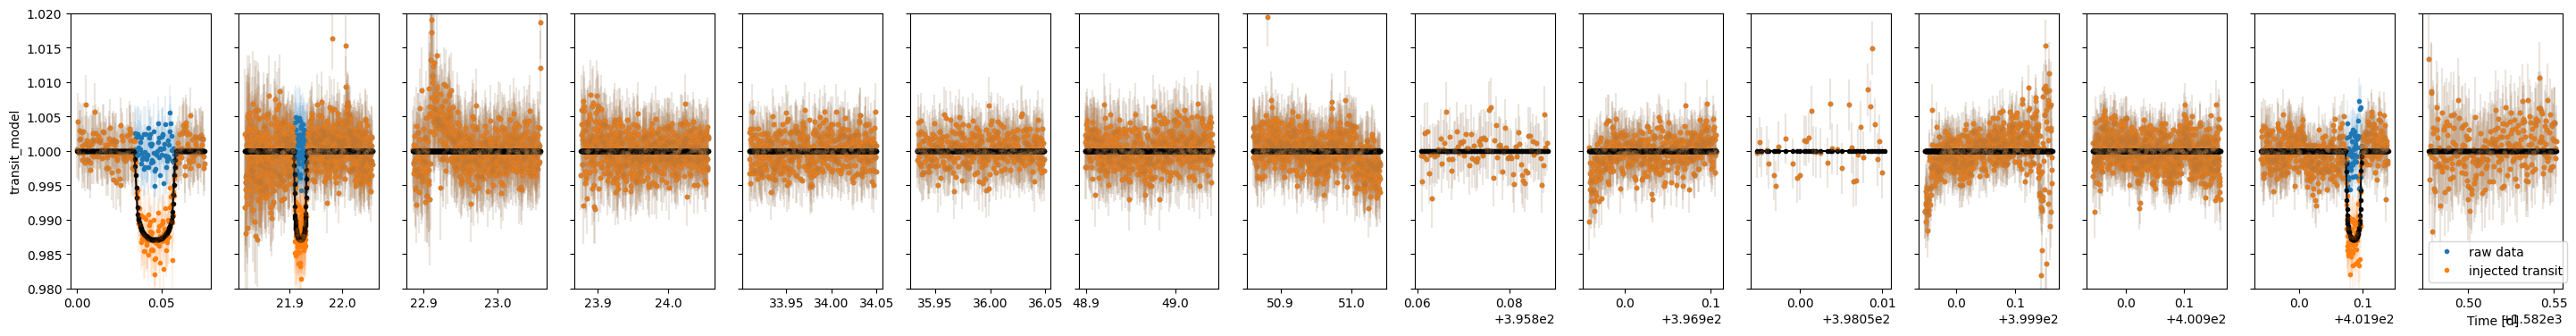

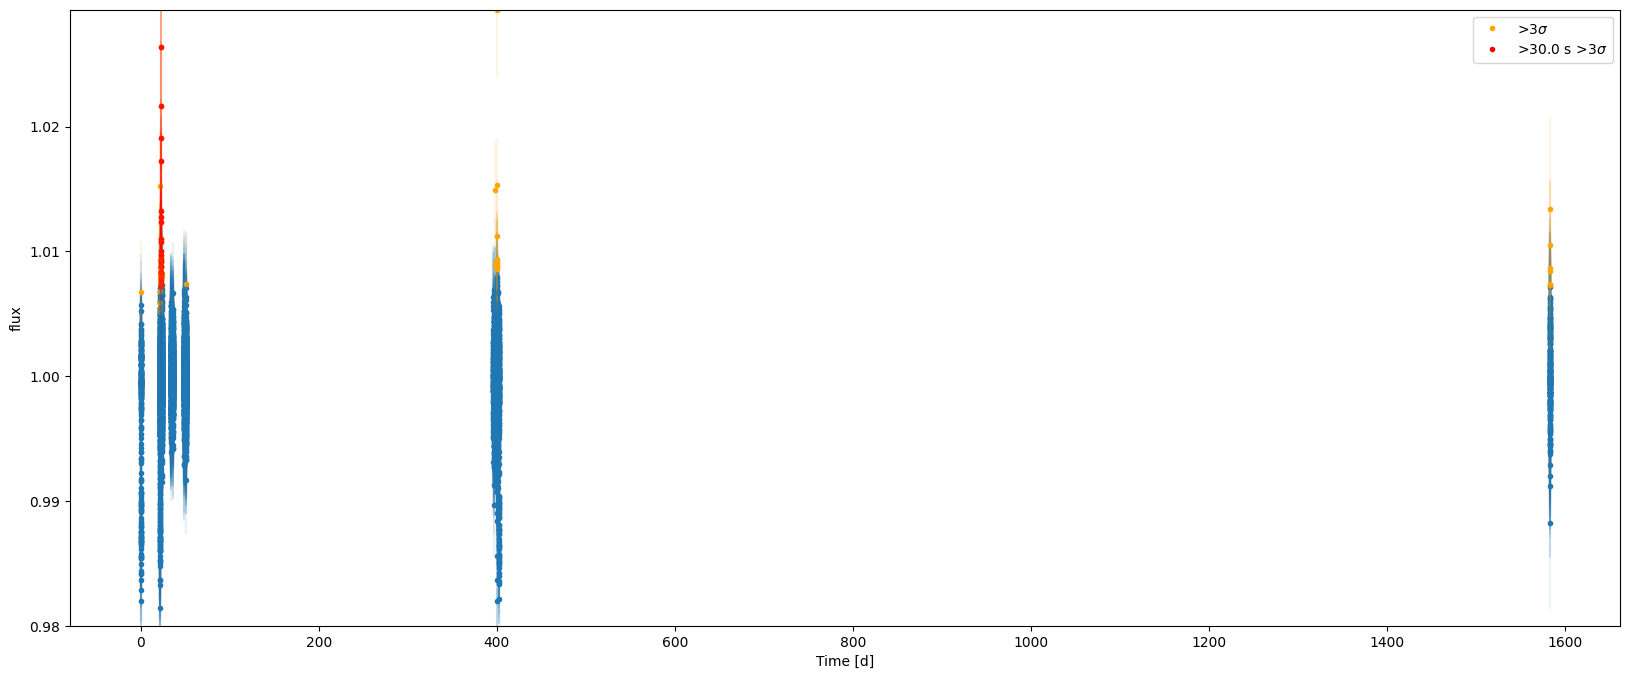

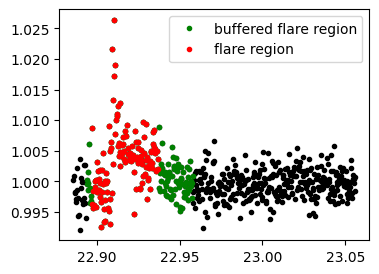

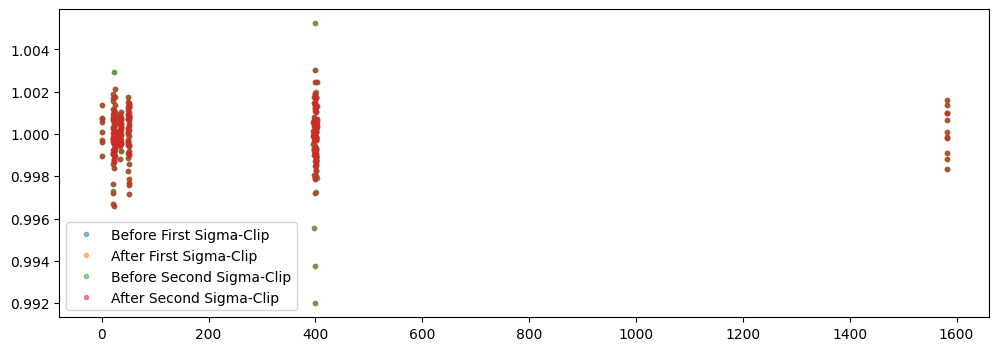

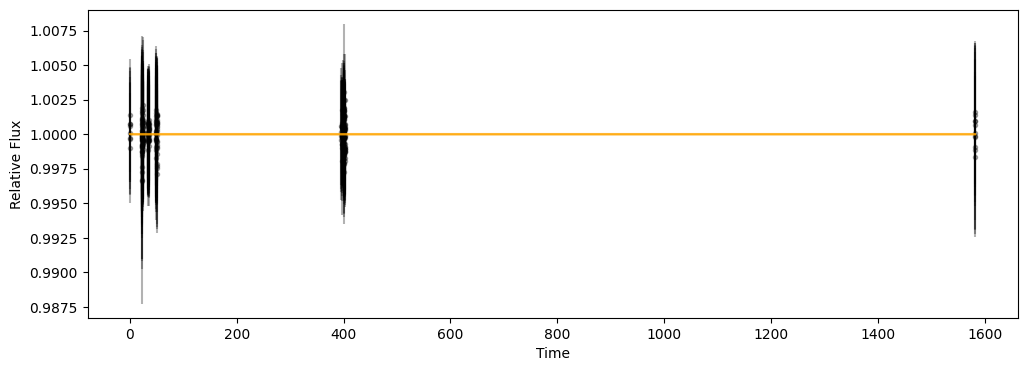

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved LC as: ../../Results//file_007_inject3_clean_sigmaclipped_flaresremoved_bin.pkl
Time to detrend: 6.71674108505249
Running BLS Search
Number of Periods Checked:  100000
Period:  1.3671393713547533
Duration:  0.02
Depth:  0.012002012033317404
Power:  13.051487064786498
Saved LC as: ../../Results//file_007_inject3_clean_sigmaclipped_flaresremoved_bin_bls_0.pkl
Time to BLS search: 4.6051459312438965
Transit was found - checking if it matches the injected transit!
Injected planet parameters: {'period': [<Quantity 1.36714047 d>], 'epoch': [<Quantity 0.04626009 d>], 'inc': [<Quantity 1.5700276 rad>], 'rp': [<Quantity 1.4873219 earthRad>], 'a': [<Quantity 2.48376657 solRad>], 'a_Rs': [<Quantity 19.10589671>], 'ld': [[0.3, 0.3]], 'depth': [<Quantity 0.01100175>], 'duration': [<Quantity 0.02517785 d>]}
Recovered planet parameters: {'period': [<Quantity 1.36713937 d>, <Quantity 1.36713937 d>, <Quantity 1.36713937 d>], 'depth': [0.012002012033317522, 0.012002012033317522, 0.01200201203331752

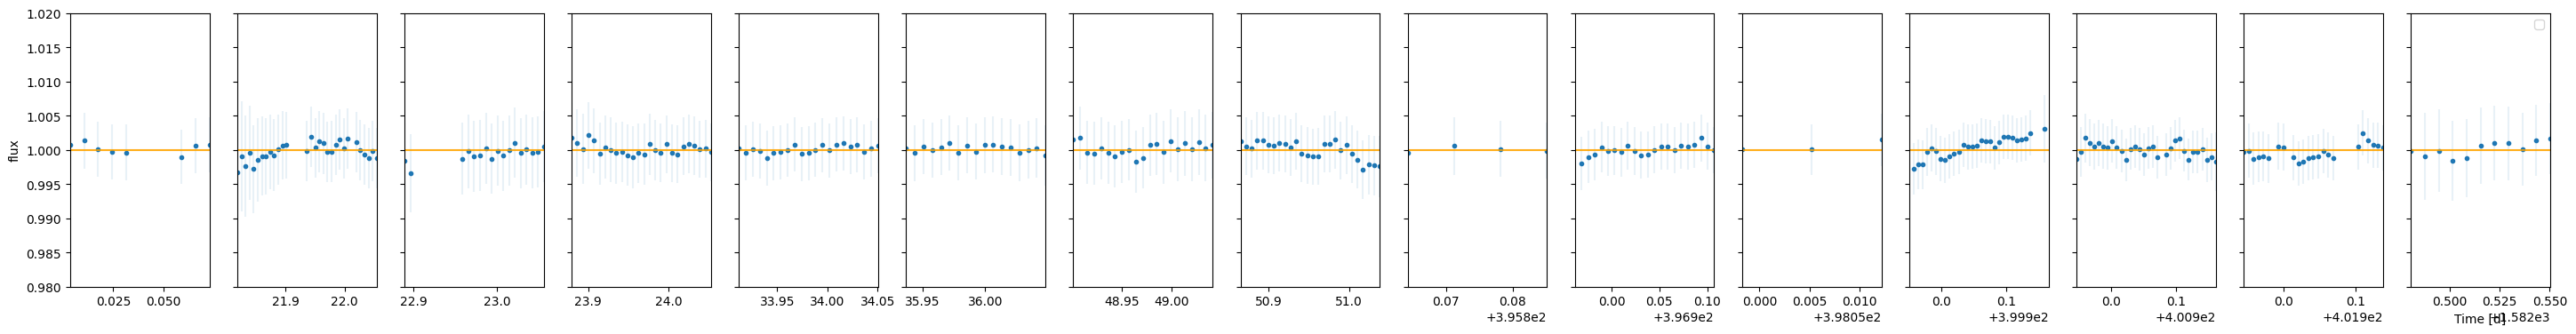

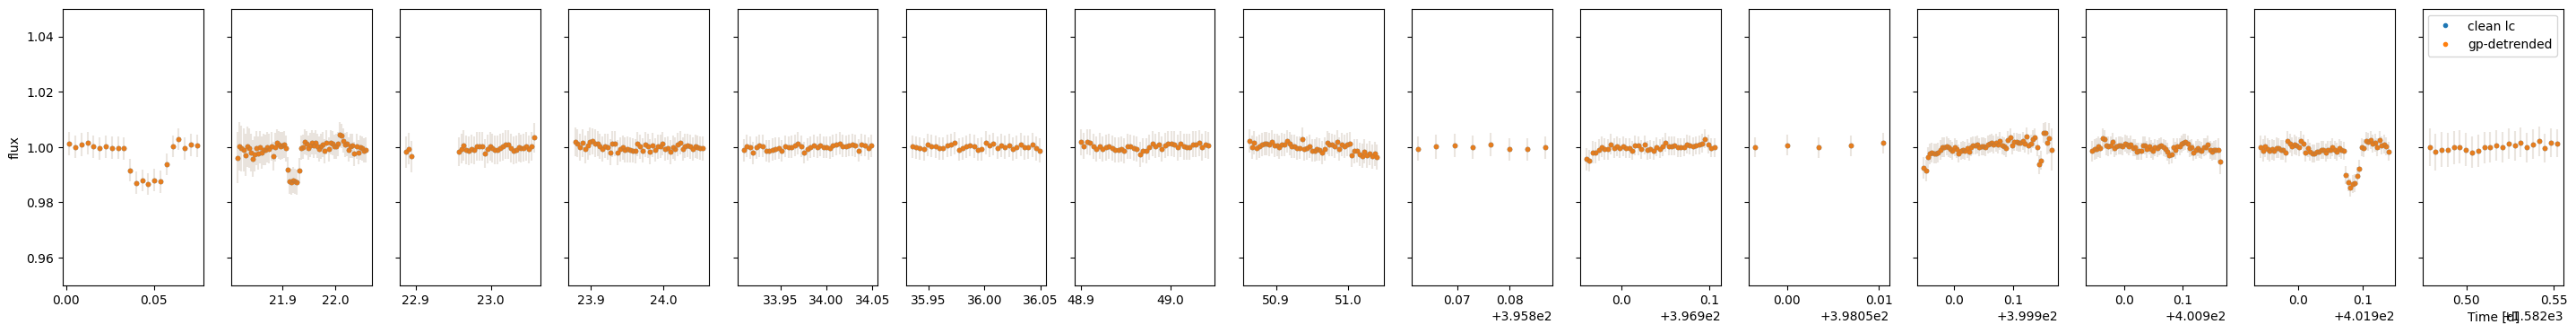

In [14]:
x = full_injection_recovery(targ, 
                            # lcs_with_transits=[targ_with_transit],
                                # planets=planets,
                             nfake=5,
                             minimum_planet_radius=1 * u.R_earth, 
                             maximum_planet_radius=2 * u.R_earth,
                             minimum_period=1 * u.d, 
                             maximum_period=3 * u.d, 
                             ld=[0.3,0.3],
                             clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                         'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':True},
                             flare_kw = {'plot':True, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                         'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                         'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf}, 
                                         'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                             detrend_method = "gp", 
                             detrend_bin = 10 * u.minute,
                             detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                           'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': True, 'verbose':True,
                                           'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                           'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                 np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                            bls_kw = {"minimum_period":0.5, "maximum_period":30, 'minimum_n_transit':2, 'obj':'snr',
                                      'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 'plot':True, 
                                      'verbose': False, 'nperiods':100000, 'oversample':10,}, 
                            bls_bin=5 * u.minute,
                            recovery_kw = {'condition_on_epoch':1 * u.hour, 
                                           'min_n_transits': 1, 
                                           'meet_condition': 'any',
                                          'verbose':True},                           
                            verbose=True, plot=True, time_this_process=True,
                           plot_dir='../../Results/', save_plots=True, save_lcs=True,
                           # plot_kw={'ylims':[0.98,1.02]},
                           svname=f"../../Results/{name}_injected_planets.csv",)

In [ ]:
# time_to_clean = 19.79s -> now 10s
# time_to_remove_flares = 42.86s -> now 37.47s

In [15]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [16]:
lcs_bls[1]

[<🌟 Lightcurve file_007_inject1_clean_sigmaclipped_flaresremoved_bin_bls_0 (609t) 🌟>]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


False


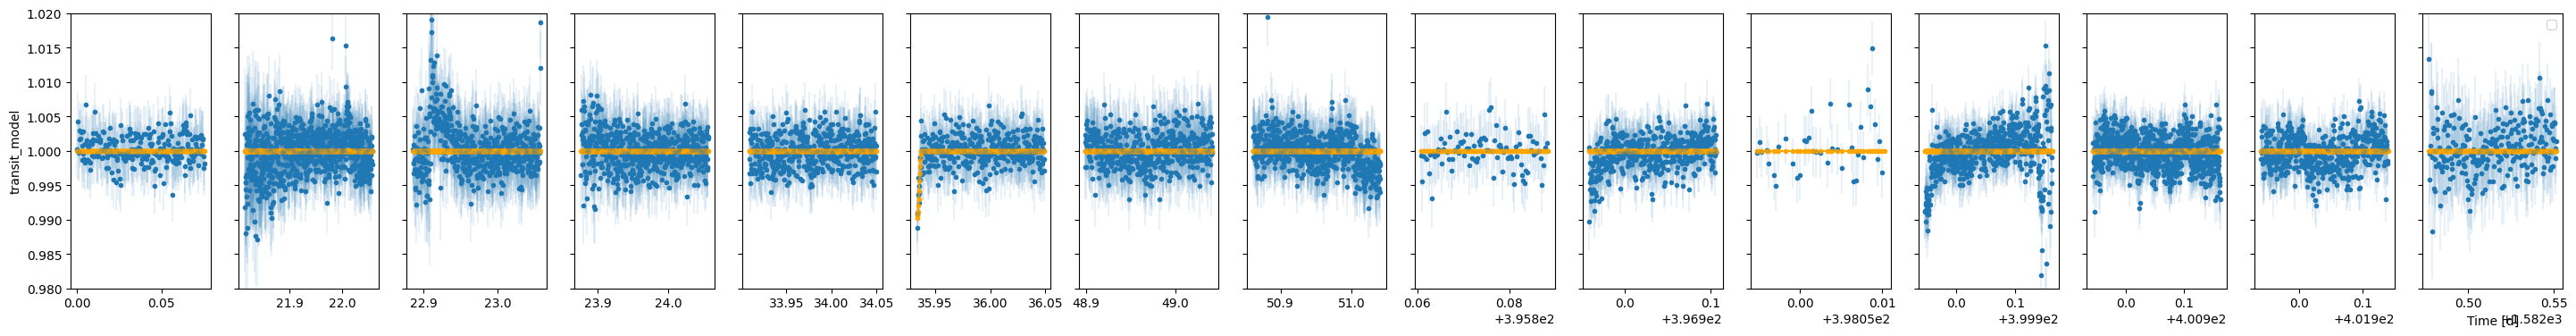

In [17]:
i=4
ax=lcs[i].plot()
lcs[i].plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
try:
    print(lcs_bls[i][0].metadata['BLS_transits_found'])
except:
    print(False)
    pass

In [18]:
# np.sqrt(planets_df['rec_depth']).values * 
from astropy.units import Quantity
planets_df['r_s'].apply(Quantity)

0    0.13 solRad
1    0.13 solRad
2    0.13 solRad
3    0.13 solRad
4    0.13 solRad
Name: r_s, dtype: object

Text(0.5, 0, 'Planet Radius [R_earth]')

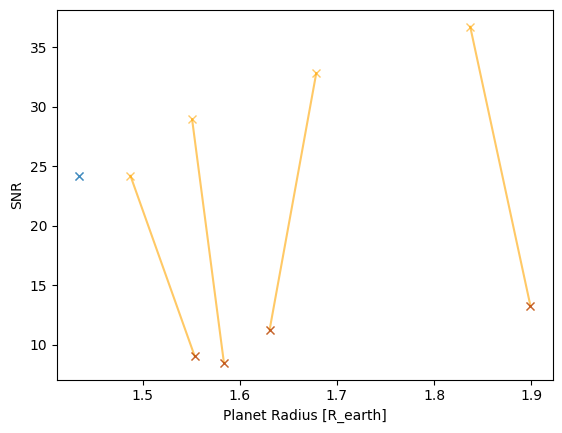

In [19]:
from astropy.units import Quantity

n_points_in_transit = planets_df['duration']/(7.5/(24*60))
lc_noise = 1e-3
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s'].apply(Quantity)).values]

for r_p, depth, rec, r_p_rec, snr, n in zip(planets_df['r_p'], planets_df['depth'],  planets_df['recovered'],rec_r_p,  planets_df['snr'], n_points_in_transit):
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
    if r_p_rec == 0.0:
        r_p_rec = r_p
        snr = depth * np.sqrt(n)/lc_noise
    plt.plot([r_p,r_p_rec], [depth * np.sqrt(n)/lc_noise, snr], 'x-', color=color, alpha=0.6)
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5)
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


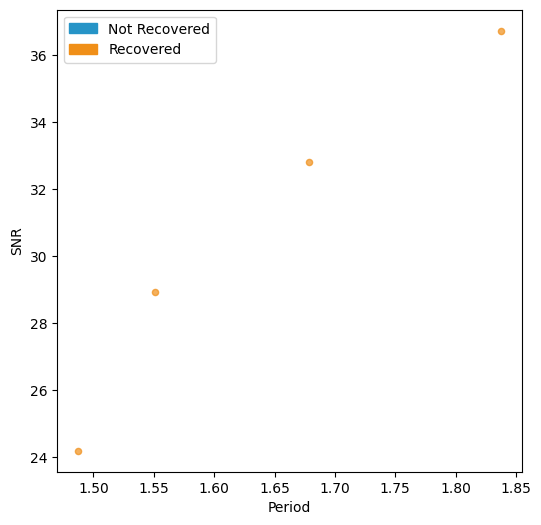

In [20]:
plot_transitparams(x=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Period", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=20,
                   svname="")